# Inpainting with GPR-LIM



In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import glob
import sys

sys.path.append('/Users/alliswell48/radio_gpr_work/shao/gprlim')
import gprlim
from gprlim import kernels

from pyuvdata import UVData
import bayeslim as ba

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
sys.path.append('../')
import gp_utils

In [4]:
import gpytorch
gpytorch.settings.max_cholesky_size._set_value(1_000)

In [5]:
torch.set_default_dtype(torch.float64)
device = 'cpu'

In [6]:
#总数据：(Nbls, Ntimes, Nfreq, Npol)=(242,1600,600,4)
#这里的file (110,1600,600,4)，thus:110*(110+1)/2= 6105 个baseline，200组（每组位置矢量相同）
#(Nbls, Ntimes, Nfreq, Npol)=(1,200,400,1)

In [7]:
# specify frequency channels
# by default, use equal to or less than 200 time integrations
# by default, use about 300-400 frequency channels
freq_chans = range(200, 600)
time_ints = range(300, 500)

# pick a representative baseline to load and model (start with 0)
bl = (0, 5)

In [8]:
# specify data
dfile = 'gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5' #需要自己产生redundant baselibne
#dfile = sorted(glob.glob('../zen.h6c_idr2_validation.24582*.sum.coupled.h5')) #已经自动包含redundant baselibne

In [9]:
# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=['ee'], time_ints=time_ints, freq_chans=freq_chans,
) #取auto (0,0) baselines
autocorr = vd.data[0,0]  #不是取baselines,是去掉前两维-》[1, 1, 1, 200, 400]->[1, 200, 400] =(baselines,Ntimes, Nfreq)

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']
# 它的meta文件:包含ant所有的1/4,  6105 baselines;分为20组（每组位置矢量相同；
#但实际上‘zen.h6c_idr2_validation.sum.uvh5'只含有(0,n)代表组基线数据
#而上面的load_uvdata( bls=[(0, 0)])只加载了一组

# get noise standard deviation
#meta['times']:day->s
#meta['freqs']:Hz
#formla sigma^2 = Vii * Vjj / Delta t / Delta nu.
#=>sigma (noise standard deviation)= Vjj / np.sqrt(Delta t / Delta nu)
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

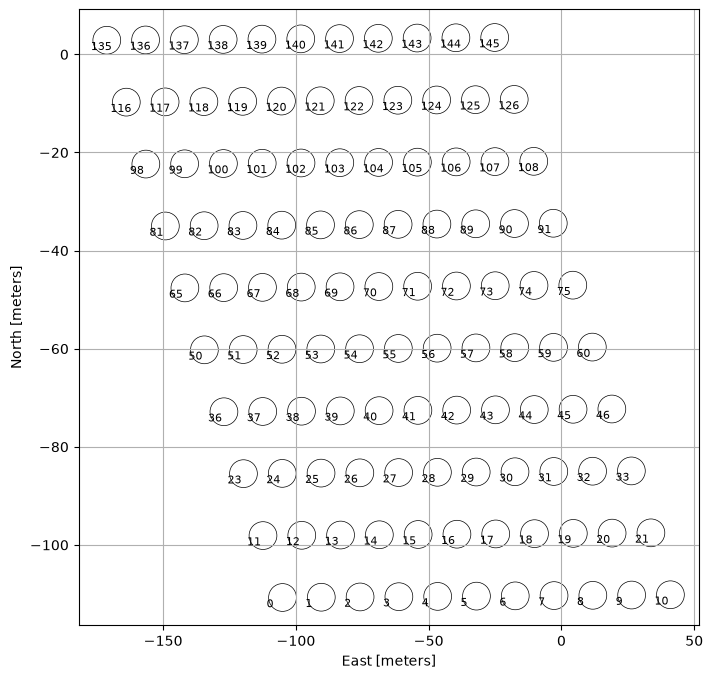

In [10]:
plt.figure(figsize=(8,8))
plt.scatter(*antpos[:, :2].T, fc='none', ec='k', s=400, lw=.5)  #画所以ant，x,y 位置
for i, a in enumerate(ants):
    plt.text(antpos[i,0]-6, antpos[i,1]-2, a, fontsize=8)
plt.xlabel('East [meters]'); plt.ylabel('North [meters]'); plt.grid();

# load redundant data

load a single redundant baseline

In [11]:
# pick a representative baseline to load and model (start with 0)
#bl = (0, 2)

# this gets the index in the redundant set that this baseline falls in
red_ind = np.where([bl in red for red in reds])[0][0] #bl 属于第几组
bls = reds[red_ind][:] #该组所有成员
bl_vec = antp[bls[0][1]] - antp[bls[0][0]] #bls是该组 所有baselines的 位置矢量bls,选bls[0]->bl = (0, 2)
bl_len = bl_vec.norm()  #bl = (0, 2) 的baselines长度

In [12]:
# load single baseline data
#bl = (0, 2)
#(Nbls, Ntimes, Nfreq, Npol)=(1,200,400,1)
vd, meta = gp_utils.load_uvdata(
    dfile,
    bls=bls,
    time_ints=time_ints,
    freq_chans=freq_chans,
    pols=['ee'],
    device=device,
)
freqs = meta['freqs'] / 1e6   #Hz-> GHz
lsts = meta['lsts']  #day
times = (meta['times'] - meta['times'][0]) * 24 * 3600  #day->s
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']   #所有baselibe编号；包括redudant，虽然只有(0,n)的baseline有数据，其他没有

Antenna pair (1, 6) does not have any data associated with it.
Antenna pair (2, 7) does not have any data associated with it.
Antenna pair (3, 8) does not have any data associated with it.
Antenna pair (4, 9) does not have any data associated with it.
Antenna pair (5, 10) does not have any data associated with it.
Antenna pair (11, 16) does not have any data associated with it.
Antenna pair (12, 17) does not have any data associated with it.
Antenna pair (13, 18) does not have any data associated with it.
Antenna pair (14, 19) does not have any data associated with it.
Antenna pair (15, 20) does not have any data associated with it.
Antenna pair (16, 21) does not have any data associated with it.
Antenna pair (23, 28) does not have any data associated with it.
Antenna pair (24, 29) does not have any data associated with it.
Antenna pair (25, 30) does not have any data associated with it.
Antenna pair (26, 31) does not have any data associated with it.
Antenna pair (27, 32) does not hav

In [13]:
inflate_data = True
if inflate_data and vd.Nbls == 1:
    vd = vd.inflate_by_redundancy(bls=reds[red_ind]) #reds[red_ind]是bl = (0, 2)对应的组的所有redundant成员
    
#[1, 1, 1, 200, 400]->[1, 1, 90, 200, 400]    
    

In [14]:
add_noise = False
if add_noise:
    vd.data += torch.randn_like(vd.data) * noise_amp * 1e-3

In [15]:
# look at how large the data is
print("size of data in MB: {:.1f}".format(vd.data.nbytes/1e6))

size of data in MB: 76.8


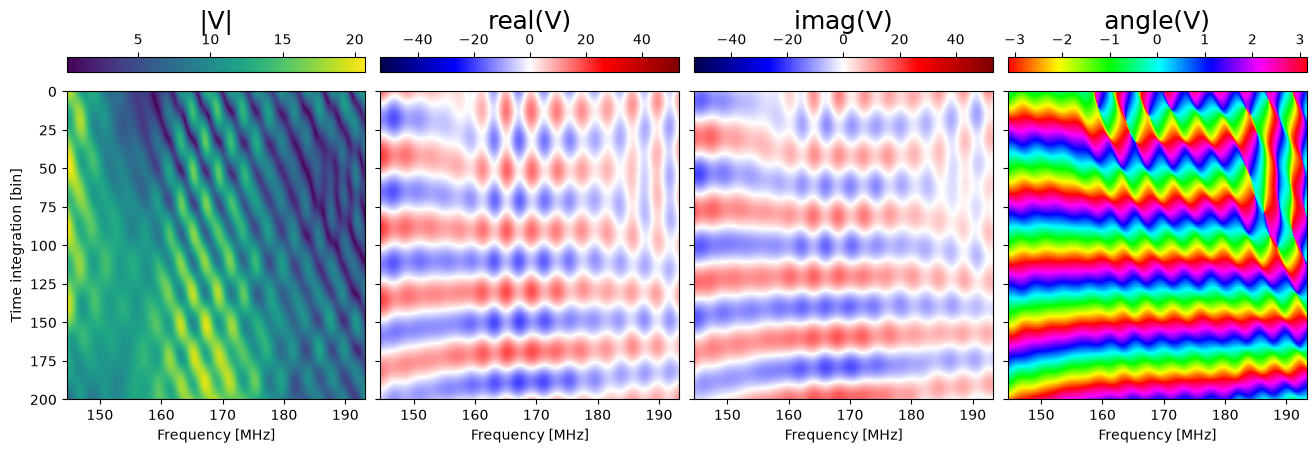

In [16]:
# plot the data (called a waterfall)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)
dstd = vd.data.std()

#[1, 1, 90, 200, 400] 
#vd.data[0,0,0] 意思是[0,0,0, 200, 400] 

# visibility amplitude (abs)
cax = axes[0].imshow(vd.data[0,0,0].abs(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_title("|V|", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[0], location='top');
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time integration [bin]');

# visibility real
cax = axes[1].imshow(vd.data[0,0,0].real, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[1].set_title("real(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[1], location='top');
axes[1].set_xlabel('Frequency [MHz]'); axes[1].set_yticklabels([])

# visibility imag
cax = axes[2].imshow(vd.data[0,0,0].imag, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[2].set_title("imag(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[2], location='top');
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_yticklabels([]);

# visibility phase
cax = axes[3].imshow(vd.data[0,0,0].angle(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='hsv')
axes[3].set_title("angle(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[3], location='top');
axes[3].set_xlabel('Frequency [MHz]'); axes[3].set_yticklabels([]);

In [17]:
from bayeslim.fft import FFT
# vd.data.shape [1, 1, 90, 200, 400]

# 1D FT across frequency, (200, 400)-> (time,fre)
#fre fft: V(t, ν)->V(t, τ)
FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)  
# fre: unit GHz*1e3, fft -> tau: unit: s/(G*1e3)=s/1e9=ns

#time fft: V(t, ν)->V(f_r, ν)
# 1D FT across time
FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)  
# time-> unit 1000 second=> fft ->fringe rate: unit: mHz

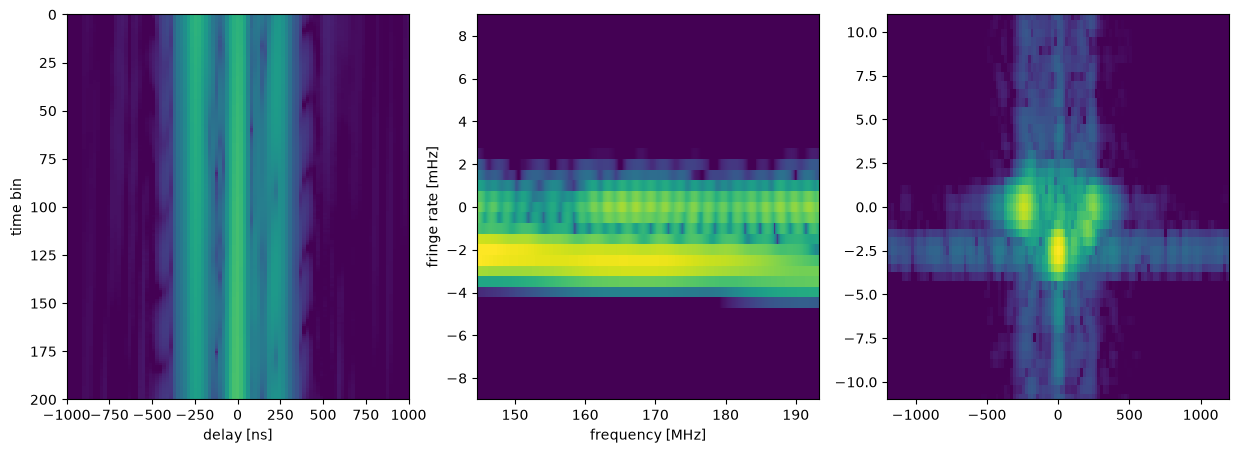

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#[1, 1, 90, 200, 400]-> 取baseline 0；[1, 1, , 200, 400]
#pytorch: [ 200, 400] 从右边开始broadcasting=> [ 1,1,200, 400]，所以ndim=2也可以
axes[0].imshow(FT1(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], Ntimes, 0])
axes[0].set_xlim(-1000, 1000); axes[0].set_xlabel('delay [ns]'); axes[0].set_ylabel('time bin')

axes[1].imshow(FT2(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=0, vmax=3,
               extent=[freqs[0], freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_ylim(-9, 9); axes[1].set_xlabel('frequency [MHz]'); axes[1].set_ylabel('fringe rate [mHz]')

axes[2].imshow(FT1(FT2(vd.data))[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11);

### specify the time kernel

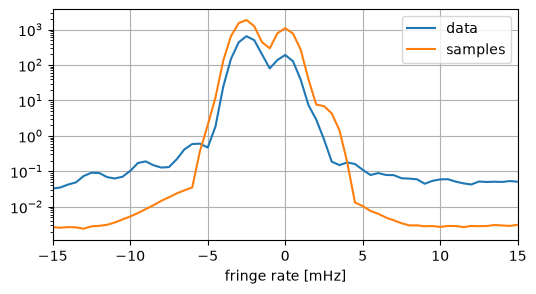

In [19]:
import os
import time
from utils_inpaint import make_flags,make_time_kernel,make_freq_kernel


time_kernel = make_time_kernel(
    kernel_type="custom",
    freqs=freqs,
    bl_vec=bl_vec,
    lat=meta["lat"],
    default_buf=1.0,
    default_min_hw=0.5,
)

# draw samples from the time covariance: increase jitter if not positive definite
samples = gprlim.models.prior_draws_1d(time_kernel, times, size=100, jitter=1e-10)

# plot the covariance samples against the data
plt.figure(figsize=(6, 3))
plt.plot(FT2.freqs, FT2(vd.data)[0,0,0].abs().mean(1), label='data')
plt.plot(FT2.freqs, FT2(samples.T).abs().mean(1), label='samples');
plt.xlim(-15, 15); plt.xlabel('fringe rate [mHz]'); plt.legend(); plt.yscale('log'); plt.grid()




### specify the frequency kernel

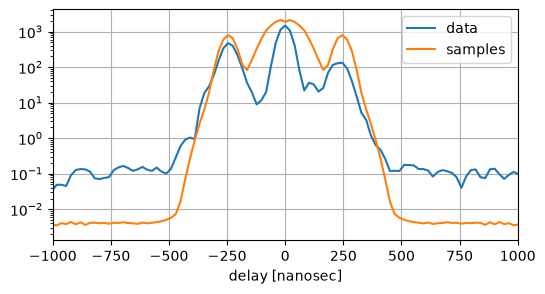

In [20]:
kernel_type = "custom"

freq_kernel = make_freq_kernel(
    kernel_type=kernel_type,
    bl_vec=bl_vec,
    default_buffer=100.0,
    default_min_delay=50.0,
)

# draw samples from the freq covariance: increase jitter if not positive definite
samples = gprlim.models.prior_draws_1d(freq_kernel, freqs, size=100, jitter=1e-10)

# plot the covariance samples against the data
plt.figure(figsize=(6, 3))
plt.plot(FT1.freqs, FT1(vd.data)[0,0,0].abs().mean(0), label='data')
plt.plot(FT1.freqs, FT1(samples).abs().mean(0), label='samples');
plt.xlim(-1000, 1000); plt.xlabel('delay [nanosec]'); plt.legend(); plt.yscale('log'); plt.grid()

In [21]:
def make_inv_wgts(flags, unflagged_var=1e-3, flagged_var=1e3):
    """
    Construct the diagonal noise variance used in GP inpainting.

    unflagged_var:
        Small variance for unflagged data, so the GP trusts these pixels.

    flagged_var:
        Large variance for flagged data, so the GP effectively ignores them
        and fills them using the covariance model.
    """
    inv_wgts = torch.ones_like(flags, dtype=torch.float64) * unflagged_var
    inv_wgts[flags] = flagged_var

    return inv_wgts

In [22]:
bl_name = f"bl_{bl[0]}_{bl[1]}"
freq_time_name = (
    f"freq_{freq_chans.start}_{freq_chans.stop}_"
    f"time_{time_ints.start}_{time_ints.stop}"
)

save_dir = os.path.join(
    "inpaint_results",
    bl_name,
    freq_time_name,
)

os.makedirs(save_dir, exist_ok=True)

print(save_dir)

inpaint_results/bl_0_5/freq_200_600_time_300_500


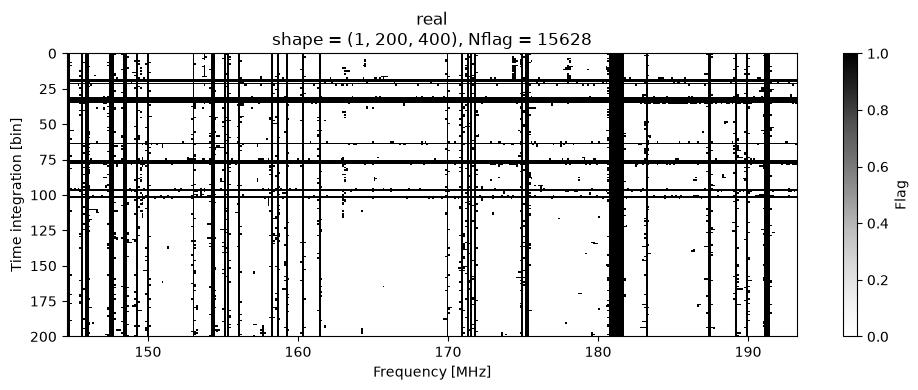

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_real.pt
Runtime: {'freq_1d': 12.478766202926636, 'time_1d_freq_1d': 14.978837966918945, 'time_freq_2d': 137.0795440673828, 'time_freq_2d_freq_1d': 118.10327219963074}


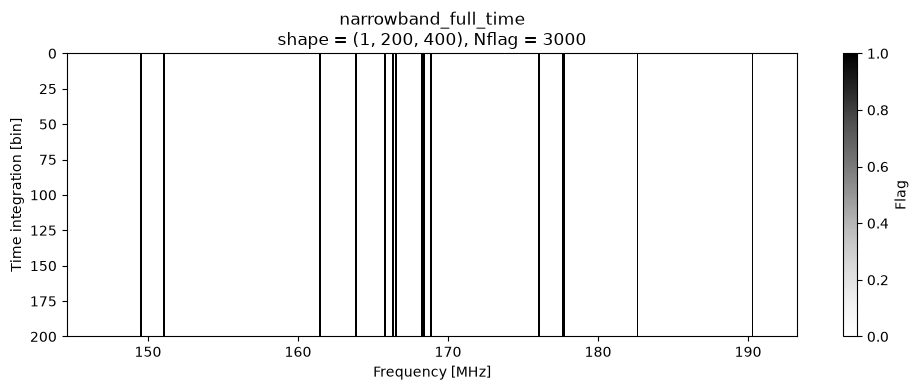

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_narrowband_full_time.pt
Runtime: {'freq_1d': 2.3748748302459717, 'time_1d_freq_1d': 2.768605947494507, 'time_freq_2d': 9.300999164581299, 'time_freq_2d_freq_1d': 22.645866870880127}


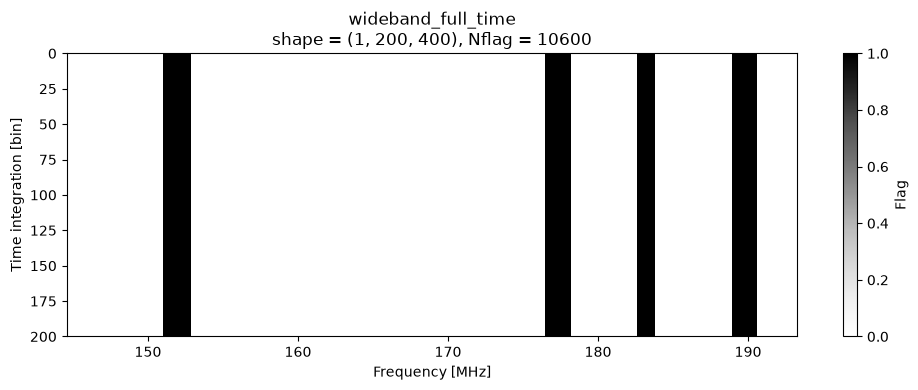

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_wideband_full_time.pt
Runtime: {'freq_1d': 7.48088812828064, 'time_1d_freq_1d': 11.145305871963501, 'time_freq_2d': 73.81801509857178, 'time_freq_2d_freq_1d': 59.70420217514038}


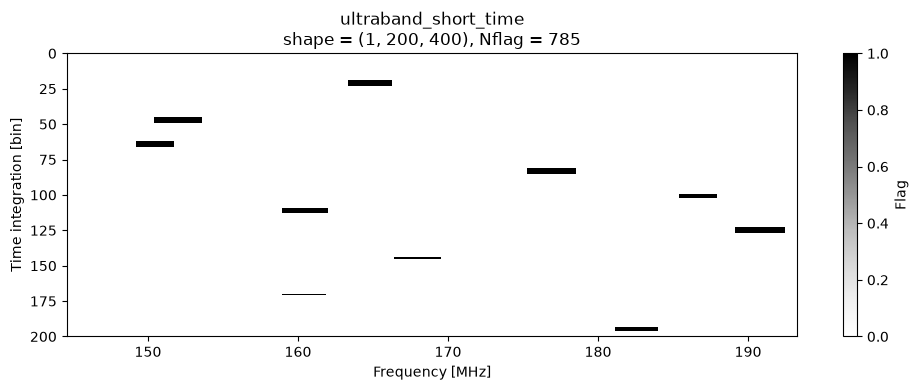

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_ultraband_short_time.pt
Runtime: {'freq_1d': 8.161910057067871, 'time_1d_freq_1d': 6.2308008670806885, 'time_freq_2d': 9.930658102035522, 'time_freq_2d_freq_1d': 11.424685001373291}


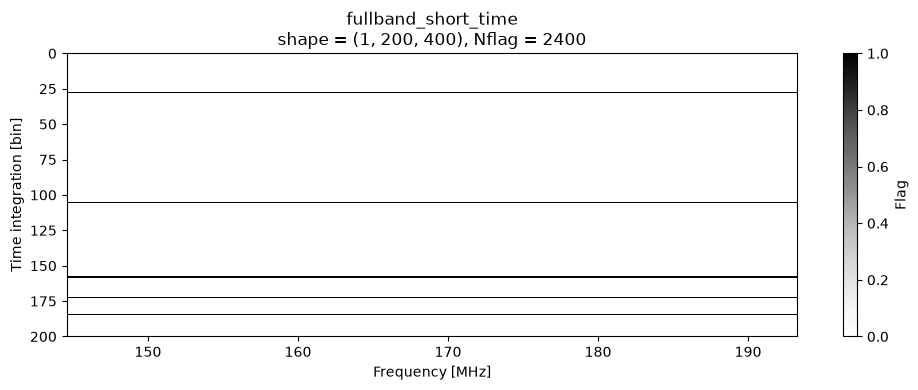

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_fullband_short_time.pt
Runtime: {'freq_1d': 6.121341943740845, 'time_1d_freq_1d': 7.563637018203735, 'time_freq_2d': 11.424243211746216, 'time_freq_2d_freq_1d': 11.143187999725342}


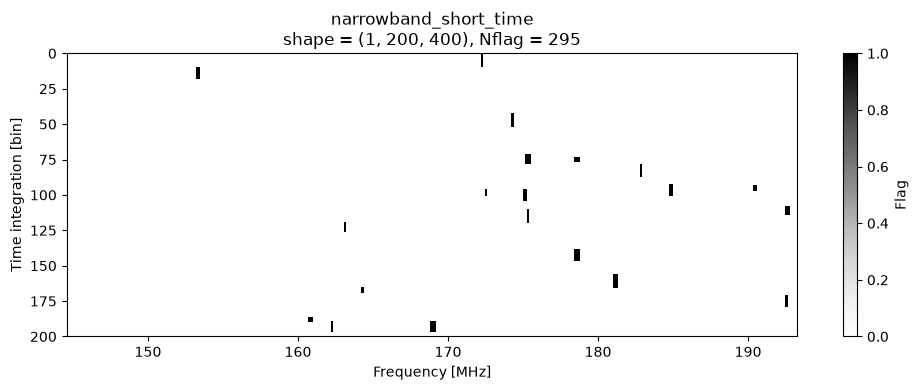

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_narrowband_short_time.pt
Runtime: {'freq_1d': 2.3339548110961914, 'time_1d_freq_1d': 3.793182134628296, 'time_freq_2d': 12.060172080993652, 'time_freq_2d_freq_1d': 17.905940055847168}


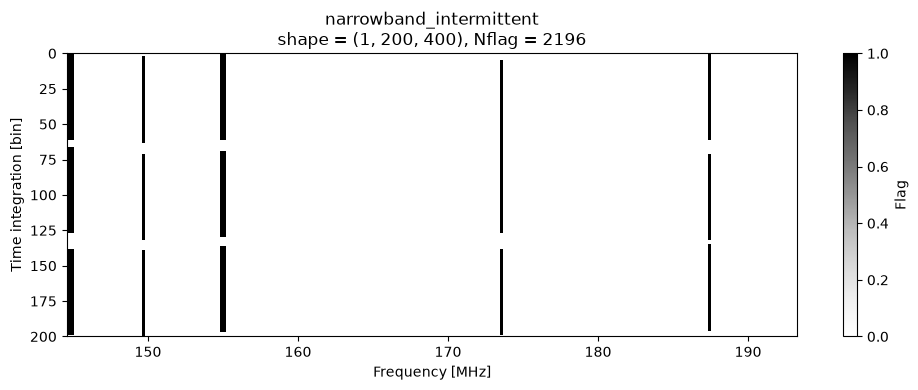

Saved: inpaint_results/bl_0_5/freq_200_600_time_300_500/inpaint_narrowband_intermittent.pt
Runtime: {'freq_1d': 1.7768399715423584, 'time_1d_freq_1d': 2.4885168075561523, 'time_freq_2d': 16.84802794456482, 'time_freq_2d_freq_1d': 36.243823289871216}


In [23]:
from utils_inpaint import make_flags,make_time_kernel,make_freq_kernel

flag_types_all = [
    ["real"],
    ["narrowband_full_time"],
    ["wideband_full_time"],
    ["ultraband_short_time"],
    ["fullband_short_time"],
    ["narrowband_short_time"],
    ["narrowband_intermittent"],

    # combined flags
    #["real", "narrowband_intermittent"],
    #["real", "wideband_full_time"],
    #["narrowband_full_time", "fullband_short_time"],
]



all_inpaint_results = {}


for flag_types in flag_types_all:
    
    # 1.load flag
    flags = make_flags(
        flag_types=flag_types,
        Ntimes=Ntimes,
        Nfreqs=Nfreqs,
        device=device,
        time_ints=time_ints,
        freq_chans=freq_chans,
    )

    flag_name = "+".join(flag_types)
    nflag = flags.sum().item()

    plt.figure(figsize=(10, 4))

    plt.imshow(
        flags[0].detach().cpu(),
        cmap="Greys",
        aspect="auto",
        interpolation="none",
        extent=[freqs[0], freqs[-1], Ntimes, 0],
    )

    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Time integration [bin]")

    plt.title(
        f"{flag_name}\n"
        f"shape = {tuple(flags.shape)}, "
        f"Nflag = {nflag}"
    )

    plt.colorbar(label="Flag")
    plt.tight_layout()
    plt.show()
    
    
    # --------------------------------------------------
    # 4.3 Prepare result dictionary for this flag case
    # --------------------------------------------------
    result_this_flag = {
        "flag_name": flag_name,
        "flag_types": flag_types,
        "flags": flags.detach().cpu(),
        "nflag": nflag,
        "inpaint": {},
    }

    inv_wgts = make_inv_wgts(flags)

    # ==================================================
    # 2. Inpainting methods
    # ==================================================

    # --------------------------------------------------
    # 5.1 1D frequency inpainting
    # --------------------------------------------------
    t0 = time.time()

    inp_y, mdl = gp_utils.inpaint_freq_1d(
        vd,
        flags,
        freq_kernel,
        inv_wgts,
        method="woodbury",
        rcond=1e-12,
    )

    result_this_flag["inpaint"]["freq_1d"] = {
        "inp_y": inp_y.detach().cpu(),
        "mdl": mdl.detach().cpu() if torch.is_tensor(mdl) else mdl,
        "runtime_sec": time.time() - t0,
    }

    # --------------------------------------------------
    # 5.2 1D time + 1D frequency inpainting
    # --------------------------------------------------
    t0 = time.time()

    inp_y, mdl = gp_utils.inpaint_time_freq_1d(
        vd,
        flags,
        time_kernel,
        freq_kernel,
        inv_wgts,
        method="woodbury",
        rcond=1e-12,
        noise_mult=100,
    )

    result_this_flag["inpaint"]["time_1d_freq_1d"] = {
        "inp_y": inp_y.detach().cpu(),
        "mdl": mdl.detach().cpu() if torch.is_tensor(mdl) else mdl,
        "runtime_sec": time.time() - t0,
    }

    # --------------------------------------------------
    # 5.3 2D time-frequency inpainting
    # --------------------------------------------------
    t0 = time.time()

    inp_y, mdl = gp_utils.inpaint_time_freq_2d(
        vd,
        flags,
        time_kernel,
        freq_kernel,
        inv_wgts,
        method="cg",
        cg_tol=1e-3,
        n_threads=8,
    )

    result_this_flag["inpaint"]["time_freq_2d"] = {
        "inp_y": inp_y.detach().cpu(),
        "mdl": mdl.detach().cpu() if torch.is_tensor(mdl) else mdl,
        "runtime_sec": time.time() - t0,
    }

    # --------------------------------------------------
    # 5.4 2D time-frequency + 1D frequency inpainting
    # --------------------------------------------------
    t0 = time.time()

    inp_y, mdl = gp_utils.inpaint_time_freq_2d_freq_1d(
        vd,
        flags,
        time_kernel,
        freq_kernel,
        inv_wgts,
        cg_tol=1e-3,
        rcond=1e-12,
        n_threads=8,
        noise_mult=100,
    )

    result_this_flag["inpaint"]["time_freq_2d_freq_1d"] = {
        "inp_y": inp_y.detach().cpu(),
        "mdl": mdl.detach().cpu() if torch.is_tensor(mdl) else mdl,
        "runtime_sec": time.time() - t0,
    }

    # --------------------------------------------------
    # 5.5 Save this flag case to an individual file
    # --------------------------------------------------
    save_path = os.path.join(save_dir, f"inpaint_{flag_name}.pt")

    torch.save(result_this_flag, save_path)

    print(f"Saved: {save_path}")
    print(
        "Runtime:",
        {
            method: result_this_flag["inpaint"][method]["runtime_sec"]
            for method in result_this_flag["inpaint"]
        },
    )

In [25]:
import importlib
import utils_inpaint

importlib.reload(utils_inpaint)

<module 'utils_inpaint' from '/Users/alliswell48/radio_gpr_work/shao/utils_inpaint.py'>